In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [ ]:
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)
pd.set_option('display.max_columns', None)
df = pd.read_csv('seasonal_agriculture_performance_dataset.csv')
print('Shape:', df.shape)
df.head()


Shape: (4000, 28)


,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Irrigation_Method,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.4,24.3,69.1,5.8,7.14,32.8,75.8,61.3,91.0,Drip,242.7,4.33,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.485,55.3
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.4,25.7,78.4,5.1,5.20,32.0,82.1,35.4,121.8,Flood,271.4,6.86,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.396,49.9
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.6,23.9,56.4,10.3,5.82,8.1,118.5,51.5,117.9,Drip,162.6,6.08,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.984,33.7
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.2,29.7,65.2,6.3,5.98,23.7,138.6,55.6,115.5,Rainfed,182.2,6.39,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.160,50.6
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.6,34.1,55.2,6.5,6.90,29.3,124.1,69.0,121.4,Flood,244.9,7.61,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.829,32.3


In [ ]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 28 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Farm_ID                        4000 non-null   object 
 1   State                          4000 non-null   object 
 2   District                       4000 non-null   object 
 3   Crop                           4000 non-null   object 
 4   Season                         4000 non-null   object 
 5   Farm_Area_Hectares             4000 non-null   float64
 6   Rainfall_mm                    3952 non-null   float64
 7   Avg_Temperature_C              4000 non-null   float64
 8   Humidity_pct                   4000 non-null   float64
 9   Sunlight_Hours_Day             4000 non-null   float64
 10  Soil_pH                        4000 non-null   float64
 11  Soil_Moisture_pct              3960 non-null   float64
 12  Nitrogen_kg_ha                 4000 non-null   f

In [ ]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Farm_Area_Hectares,4000.0,7.888265,4.223764,0.500,4.260,7.8950,11.65000,15.00
Rainfall_mm,3952.0,601.152657,288.925025,80.000,370.200,582.0000,834.95000,1395.20
Avg_Temperature_C,4000.0,26.818900,3.818180,16.200,23.900,26.9000,29.60000,39.70
Humidity_pct,4000.0,63.210500,11.960834,25.000,54.775,63.0000,71.90000,95.00
Sunlight_Hours_Day,4000.0,7.323050,1.121186,3.500,6.600,7.3000,8.10000,11.00
Soil_pH,4000.0,6.701010,0.641461,5.200,6.260,6.6900,7.14000,8.40
Soil_Moisture_pct,3960.0,26.508232,6.712484,8.000,21.700,26.4000,31.30000,47.00
Nitrogen_kg_ha,4000.0,120.250825,31.216452,40.000,98.500,120.1000,141.22500,220.00
Phosphorus_kg_ha,4000.0,57.781850,17.015074,15.000,46.200,57.5000,69.40000,120.00
Potassium_kg_ha,4000.0,104.760050,27.742681,30.000,86.200,105.1000,123.60000,200.00


In [ ]:
for col in ['State', 'Crop', 'Season', 'Irrigation_Method']:
    print(f"{col} ({df[col].nunique()} unique): {sorted(df[col].unique())}")


State (8 unique): ['Andhra Pradesh', 'Gujarat', 'Karnataka', 'Madhya Pradesh', 'Maharashtra', 'Punjab', 'Tamil Nadu', 'Telangana']
Crop (8 unique): ['Chilli', 'Cotton', 'Groundnut', 'Maize', 'Pulses', 'Rice', 'Sugarcane', 'Wheat']
Season (3 unique): ['Kharif', 'Rabi', 'Zaid']
Irrigation_Method (4 unique): ['Drip', 'Flood', 'Rainfed', 'Sprinkler']


In [ ]:
df['Season'].value_counts()

,count
Season,
Kharif,1779
Rabi,1627
Zaid,594


In [ ]:
missing = df.isnull().sum()
missing = missing[missing > 0]
print('Columns with missing values:')
print(missing)
print()
print('% missing:')
print((missing / len(df) * 100).round(2))

Columns with missing values:
Rainfall_mm          48
Soil_Moisture_pct    40
Yield_Tonnes_Ha      32
dtype: int64

% missing:
Rainfall_mm          1.2
Soil_Moisture_pct    1.0
Yield_Tonnes_Ha      0.8
dtype: float64


In [ ]:
for col in ['Rainfall_mm', 'Soil_Moisture_pct', 'Yield_Tonnes_Ha']:
    df[col] = df.groupby(['Season', 'Crop'])[col].transform(lambda x: x.fillna(x.median()))

# in case a Season+Crop group had all NaN, fall back to overall median
df.fillna(df.median(numeric_only=True), inplace=True)

print('Remaining missing values:', df.isnull().sum().sum())


Remaining missing values: 0


In [ ]:
print('Duplicate rows:', df.duplicated().sum())
df.drop_duplicates(inplace=True)


Duplicate rows: 0


In [ ]:
check_cols = ['Farm_Area_Hectares', 'Rainfall_mm', 'Yield_Tonnes_Ha', 'Production_Tonnes',
              'Fertilizer_kg_ha', 'Water_Used_m3', 'Revenue_INR', 'Total_Cost_INR']
for c in check_cols:
    n_neg = (df[c] < 0).sum()
    if n_neg > 0:
        print(f'{c}: {n_neg} negative values')
print('Check complete — Profit_INR is allowed to be negative (a loss-making farm).')

Check complete — Profit_INR is allowed to be negative (a loss-making farm).


In [ ]:
df.groupby('Crop')['Yield_Tonnes_Ha'].describe()[['mean','min','max']]

,mean,min,max
Crop,,,
Chilli,1.539466,0.30,3.90
Cotton,1.225561,0.30,2.90
Groundnut,1.318137,0.30,3.02
Maize,2.716851,0.30,6.08
Pulses,0.917641,0.30,2.09
Rice,2.440899,0.30,5.70
Sugarcane,46.929049,1.39,101.44
Wheat,2.109813,0.30,4.56


In [ ]:
df['Profit_Margin_pct'] = (df['Profit_INR'] / df['Revenue_INR']) * 100
df['Cost_per_Hectare'] = df['Total_Cost_INR'] / df['Farm_Area_Hectares']
df['Is_Profitable'] = df['Profit_INR'] > 0

df[['Profit_Margin_pct', 'Cost_per_Hectare', 'Is_Profitable']].describe(include='all')


,Profit_Margin_pct,Cost_per_Hectare,Is_Profitable
count,4000.000000,4000.000000,4000
unique,NaN,NaN,2
top,NaN,NaN,True
freq,NaN,NaN,2034
mean,-45.492178,66660.084938,NaN
std,158.085472,8845.644258,NaN
min,-1461.851219,35807.382550,NaN
25%,-60.192762,60597.205943,NaN
50%,1.146236,66614.048166,NaN
75%,32.885876,72739.977527,NaN


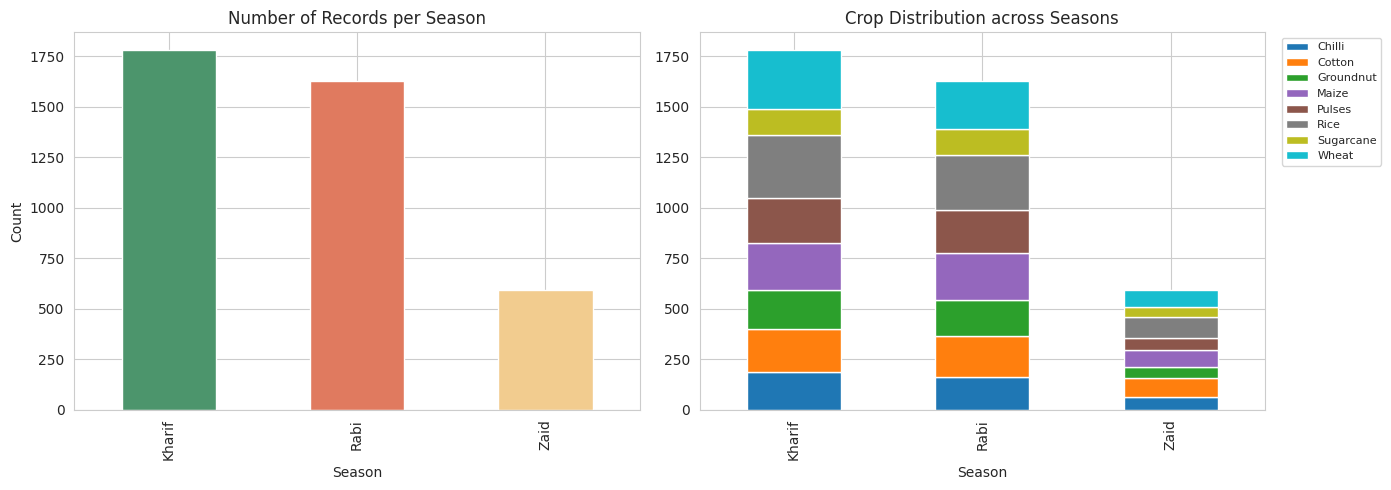

In [ ]:
season_order = ['Kharif', 'Rabi', 'Zaid']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df['Season'].value_counts().reindex(season_order).plot(kind='bar', ax=axes[0], color=['#4c956c','#e07a5f','#f2cc8f'])
axes[0].set_title('Number of Records per Season')
axes[0].set_ylabel('Count')

pd.crosstab(df['Season'], df['Crop']).reindex(season_order).plot(kind='bar', stacked=True, ax=axes[1], colormap='tab10')
axes[1].set_title('Crop Distribution across Seasons')
axes[1].legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8)

plt.tight_layout()
plt.show()


/tmp/ipykernel_676/126650002.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Season', y=col, order=season_order, ax=axes[i], palette='Set2')
/tmp/ipykernel_676/126650002.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Season', y=col, order=season_order, ax=axes[i], palette='Set2')
/tmp/ipykernel_676/126650002.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Season', y=col, order=season_order, ax=axes[i], palette='Set2')
/tmp/ipykernel_676/126650002.py:6: FutureWarning: 

Passing `palette` withou

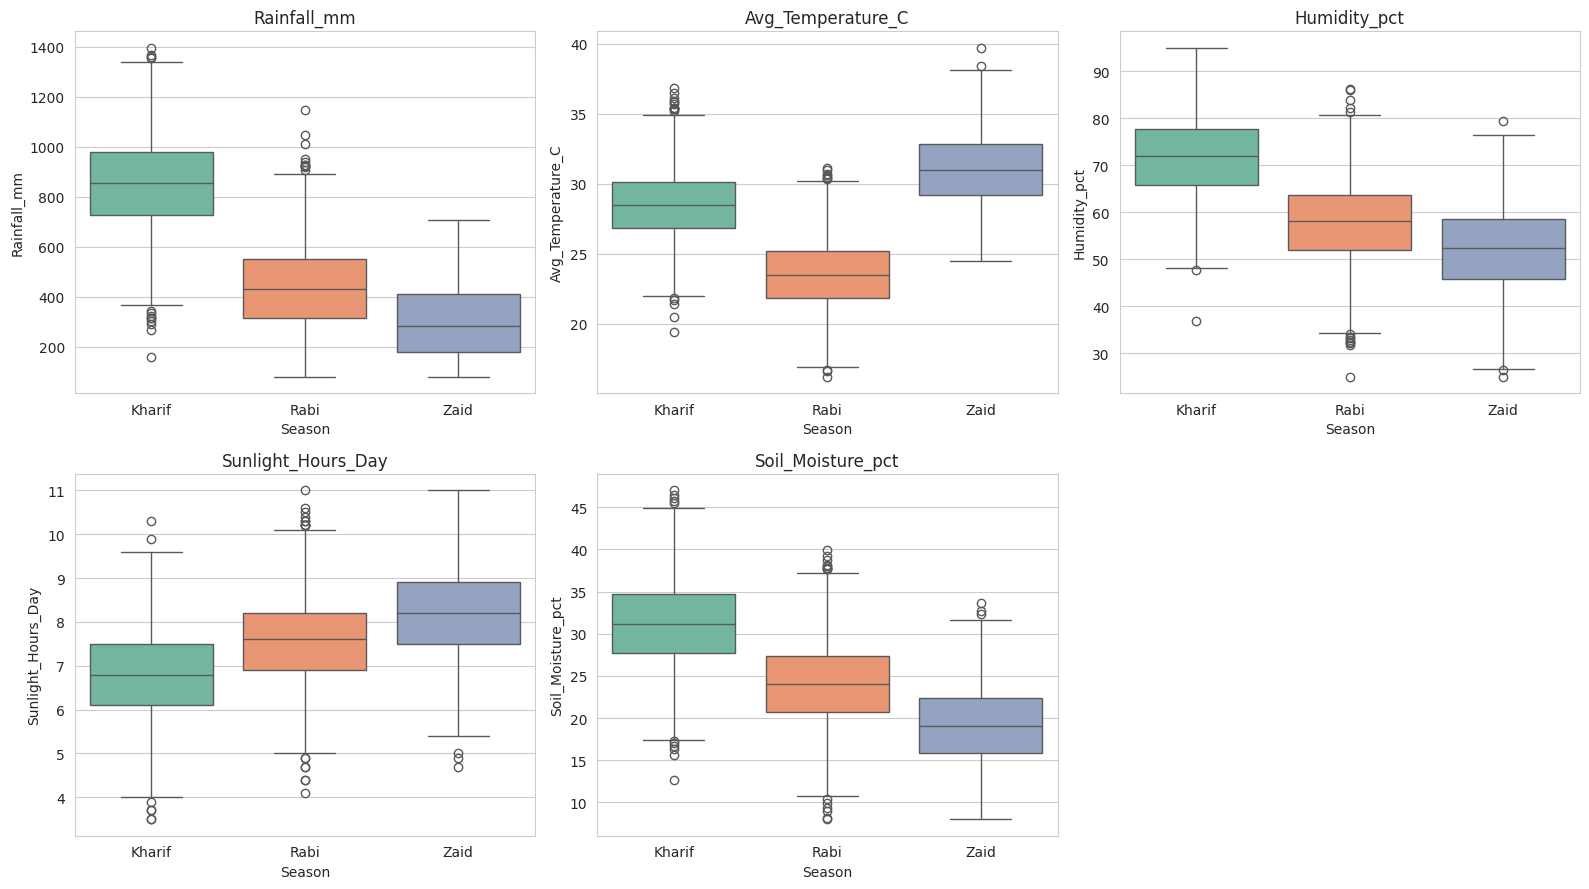

In [ ]:
env_cols = ['Rainfall_mm', 'Avg_Temperature_C', 'Humidity_pct', 'Sunlight_Hours_Day', 'Soil_Moisture_pct']

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()
for i, col in enumerate(env_cols):
    sns.boxplot(data=df, x='Season', y=col, order=season_order, ax=axes[i], palette='Set2')
    axes[i].set_title(col)
axes[-1].axis('off')
plt.tight_layout()
plt.show()


In [ ]:
df.groupby('Season')[env_cols].mean().reindex(season_order).round(2)

,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_Moisture_pct
Season,,,,,
Kharif,852.10,28.45,71.81,6.79,31.20
Rabi,435.95,23.49,57.89,7.59,24.05
Zaid,299.16,31.04,52.01,8.18,19.18


/tmp/ipykernel_676/3998641959.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='Season', y=col, order=season_order, ax=axes[i], estimator=np.mean,
/tmp/ipykernel_676/3998641959.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='Season', y=col, order=season_order, ax=axes[i], estimator=np.mean,
/tmp/ipykernel_676/3998641959.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='Season', y=col, order=season_order, ax=axes[i], estimator=np.mean,
/tmp/ipykernel_676/3998641959.py:6: FutureWarning: 

Passing `pa

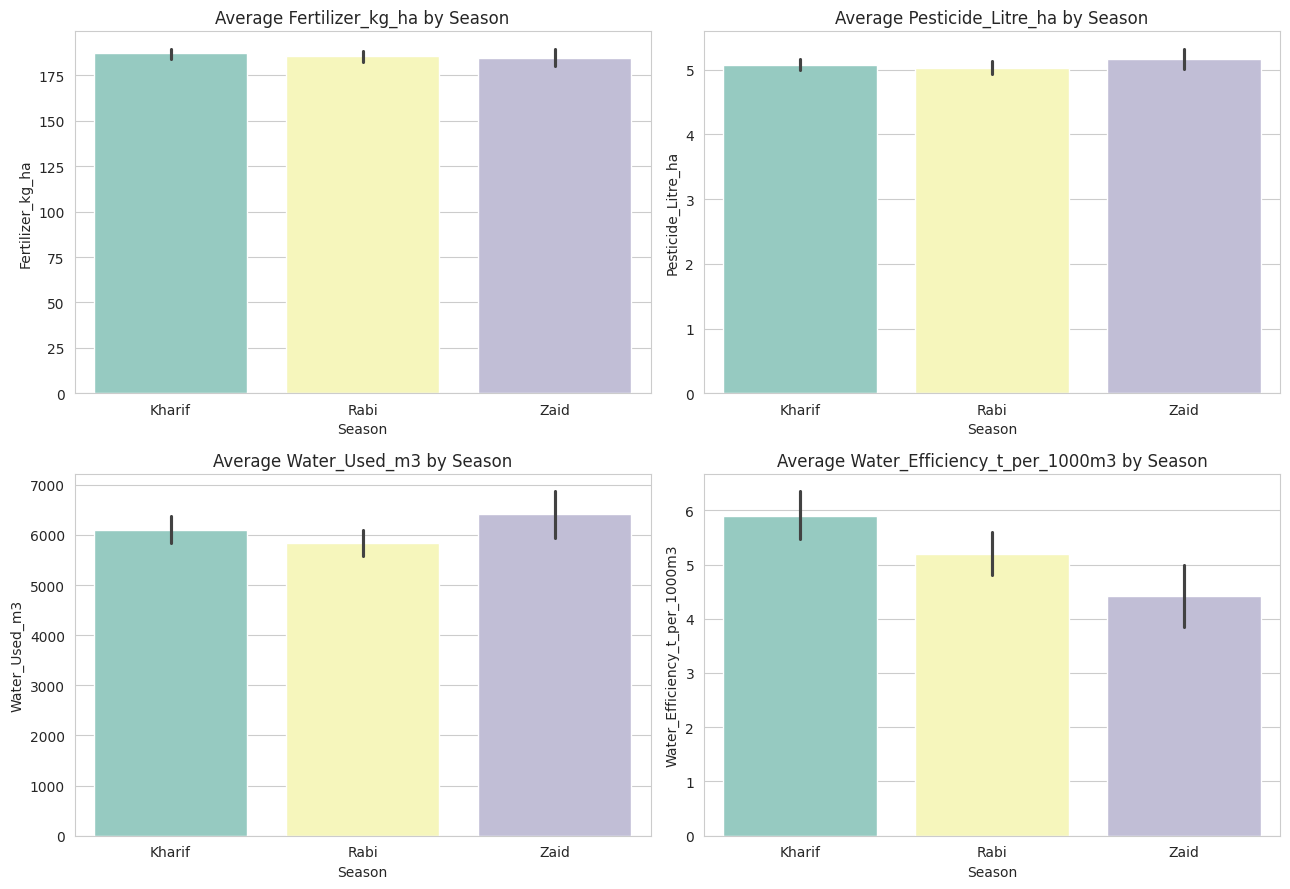

In [ ]:
resource_cols = ['Fertilizer_kg_ha', 'Pesticide_Litre_ha', 'Water_Used_m3', 'Water_Efficiency_t_per_1000m3']

fig, axes = plt.subplots(2, 2, figsize=(13, 9))
axes = axes.flatten()
for i, col in enumerate(resource_cols):
    sns.barplot(data=df, x='Season', y=col, order=season_order, ax=axes[i], estimator=np.mean,
                errorbar=('ci', 95), palette='Set3')
    axes[i].set_title(f'Average {col} by Season')
plt.tight_layout()
plt.show()

In [ ]:
pd.crosstab(df['Season'], df['Irrigation_Method'], normalize='index').reindex(season_order).round(3) * 100

Irrigation_Method,Drip,Flood,Rainfed,Sprinkler
Season,,,,
Kharif,22.8,33.2,26.0,18.0
Rabi,22.7,32.3,26.9,18.0
Zaid,23.6,32.7,23.6,20.2


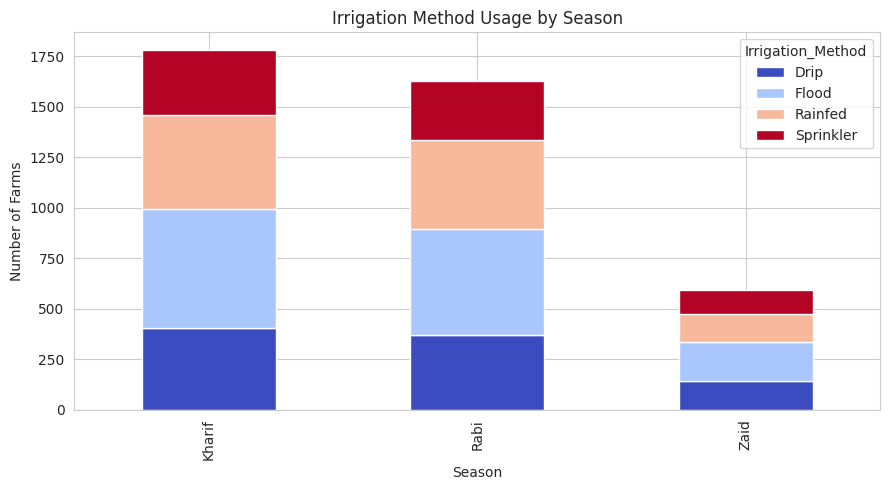

In [ ]:
plt.figure(figsize=(9,5))
pd.crosstab(df['Season'], df['Irrigation_Method']).reindex(season_order).plot(kind='bar', stacked=True, colormap='coolwarm', ax=plt.gca())
plt.title('Irrigation Method Usage by Season')
plt.ylabel('Number of Farms')
plt.tight_layout()
plt.show()

/tmp/ipykernel_676/3294818693.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Season', y='Yield_Tonnes_Ha', order=season_order, palette='Set2')


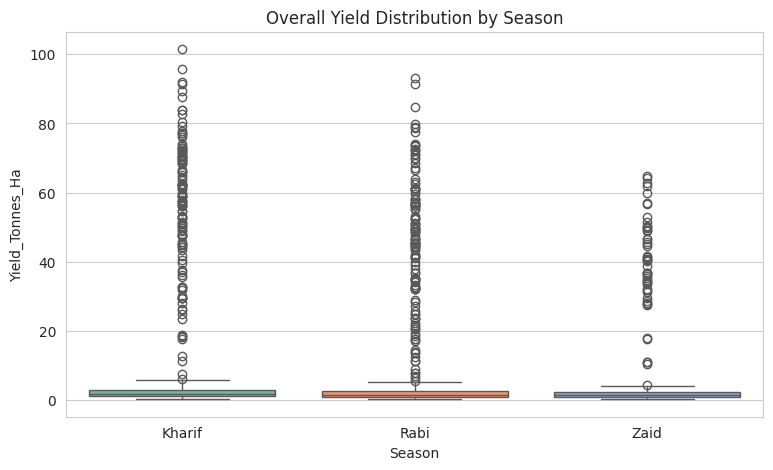

In [ ]:
plt.figure(figsize=(9,5))
sns.boxplot(data=df, x='Season', y='Yield_Tonnes_Ha', order=season_order, palette='Set2')
plt.title('Overall Yield Distribution by Season')
plt.show()


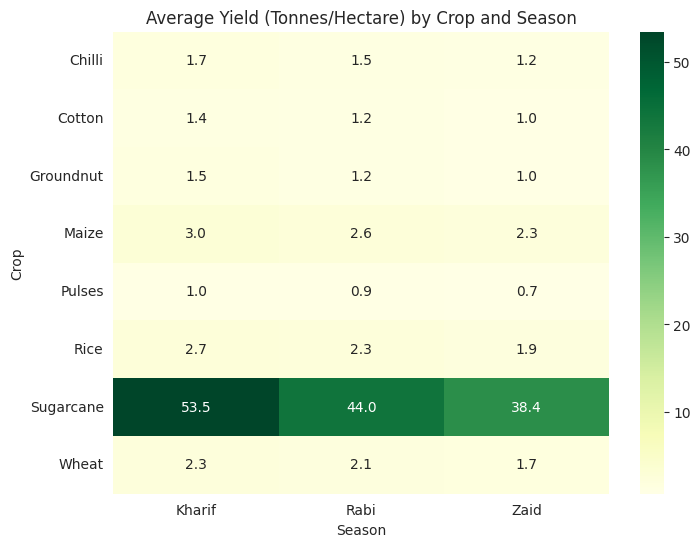

Season,Kharif,Rabi,Zaid
Crop,,,
Chilli,1.73,1.46,1.18
Cotton,1.37,1.19,0.95
Groundnut,1.48,1.22,1.04
Maize,2.97,2.62,2.30
Pulses,1.04,0.87,0.65
Rice,2.71,2.33,1.90
Sugarcane,53.46,43.96,38.42
Wheat,2.26,2.06,1.75


In [ ]:
pivot_yield = df.pivot_table(values='Yield_Tonnes_Ha', index='Crop', columns='Season', aggfunc='mean').reindex(columns=season_order)
plt.figure(figsize=(8,6))
sns.heatmap(pivot_yield, annot=True, fmt='.1f', cmap='YlGn')
plt.title('Average Yield (Tonnes/Hectare) by Crop and Season')
plt.show()
pivot_yield.round(2)

/tmp/ipykernel_676/3365629800.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Season', y=col, order=season_order, ax=axes[i], palette='Set1', showfliers=False)
/tmp/ipykernel_676/3365629800.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Season', y=col, order=season_order, ax=axes[i], palette='Set1', showfliers=False)
/tmp/ipykernel_676/3365629800.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Season', y=col, order=season_order, ax=axes[i], palette='Set1', showfliers=False)
/tmp/ipykernel_676/

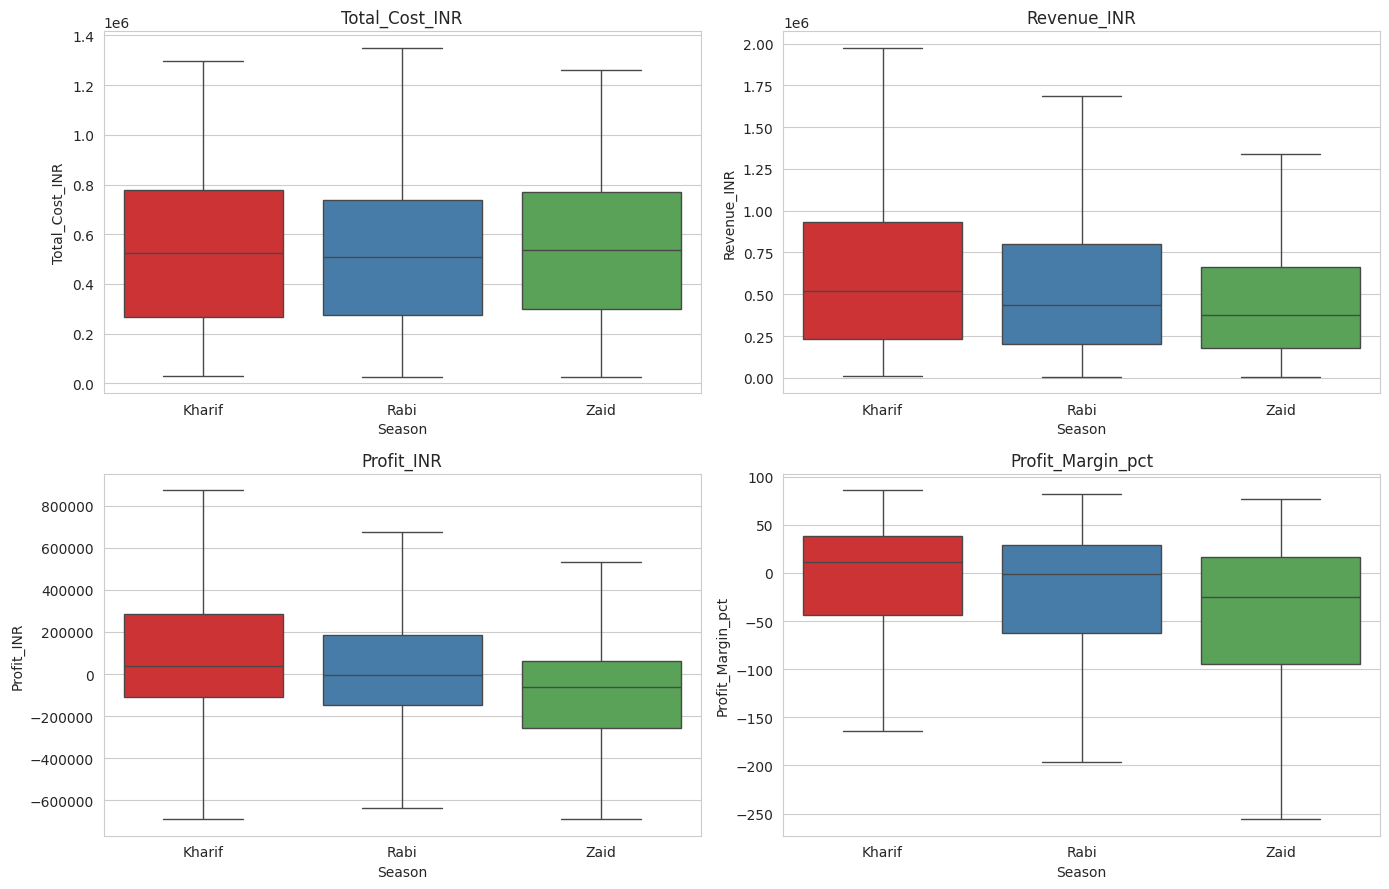

In [ ]:
econ_cols = ['Total_Cost_INR', 'Revenue_INR', 'Profit_INR', 'Profit_Margin_pct']

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
axes = axes.flatten()
for i, col in enumerate(econ_cols):
    sns.boxplot(data=df, x='Season', y=col, order=season_order, ax=axes[i], palette='Set1', showfliers=False)
    axes[i].set_title(col)
plt.tight_layout()
plt.show()


In [ ]:
df.groupby('Season')[econ_cols].mean().reindex(season_order).round(2)

,Total_Cost_INR,Revenue_INR,Profit_INR,Profit_Margin_pct
Season,,,,
Kharif,531804.41,710719.06,178914.65,-38.64
Rabi,513836.58,601526.05,87689.47,-44.27
Zaid,543976.73,519171.90,-24804.82,-69.35


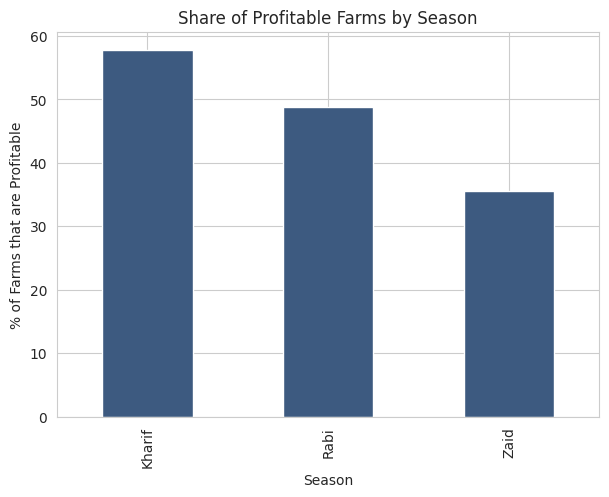

,Is_Profitable
Season,
Kharif,57.8
Rabi,48.9
Zaid,35.5


In [ ]:
profit_share = df.groupby('Season')['Is_Profitable'].mean().reindex(season_order) * 100
profit_share.plot(kind='bar', color='#3d5a80', figsize=(7,5))
plt.ylabel('% of Farms that are Profitable')
plt.title('Share of Profitable Farms by Season')
plt.show()
profit_share.round(1)

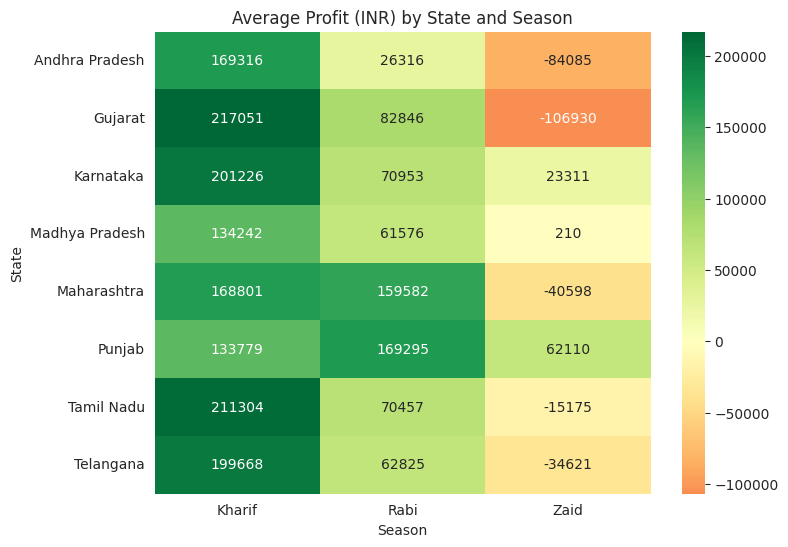

In [ ]:
pivot_profit_state = df.pivot_table(values='Profit_INR', index='State', columns='Season', aggfunc='mean').reindex(columns=season_order)
plt.figure(figsize=(8,6))
sns.heatmap(pivot_profit_state, annot=True, fmt='.0f', cmap='RdYlGn', center=0)
plt.title('Average Profit (INR) by State and Season')
plt.show()


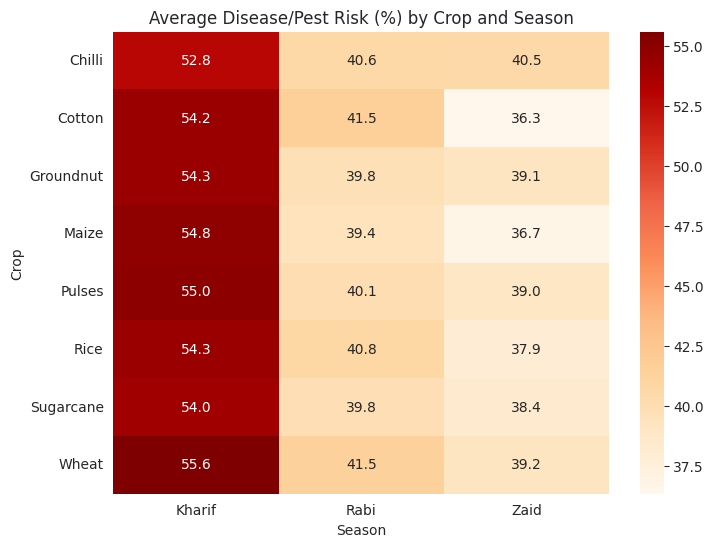

In [ ]:
pivot_risk = df.pivot_table(values='Disease_Pest_Risk_pct', index='Crop', columns='Season', aggfunc='mean').reindex(columns=season_order)
plt.figure(figsize=(8,6))
sns.heatmap(pivot_risk, annot=True, fmt='.1f', cmap='OrRd')
plt.title('Average Disease/Pest Risk (%) by Crop and Season')
plt.show()

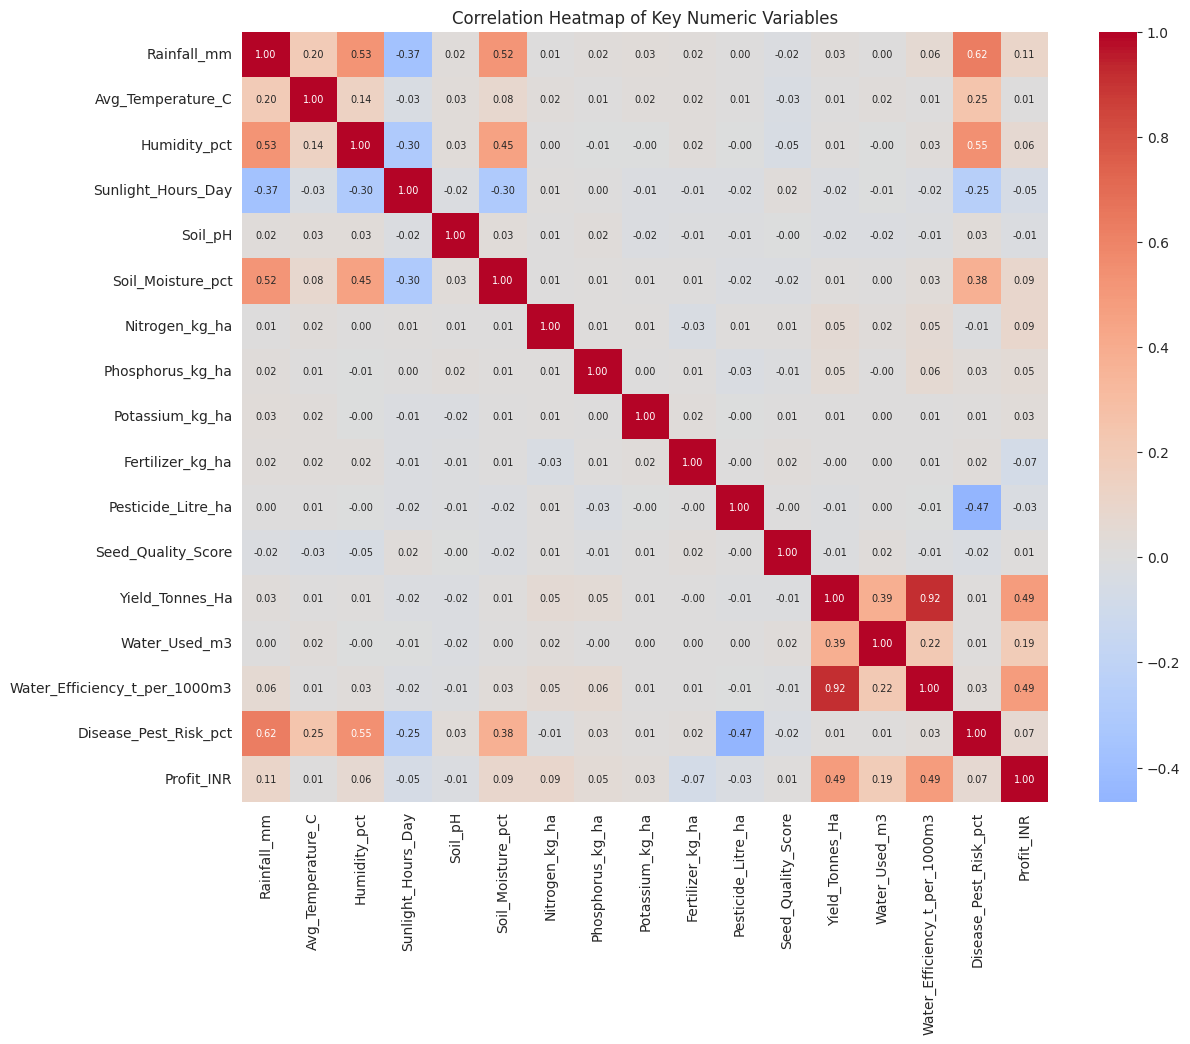

In [ ]:
num_cols = ['Rainfall_mm','Avg_Temperature_C','Humidity_pct','Sunlight_Hours_Day','Soil_pH',
            'Soil_Moisture_pct','Nitrogen_kg_ha','Phosphorus_kg_ha','Potassium_kg_ha',
            'Fertilizer_kg_ha','Pesticide_Litre_ha','Seed_Quality_Score','Yield_Tonnes_Ha',
            'Water_Used_m3','Water_Efficiency_t_per_1000m3','Disease_Pest_Risk_pct','Profit_INR']

corr = df[num_cols].corr()
plt.figure(figsize=(13,10))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, annot_kws={'size':7})
plt.title('Correlation Heatmap of Key Numeric Variables')
plt.show()


In [ ]:
print('Strongest correlations with Yield_Tonnes_Ha:')
print(corr['Yield_Tonnes_Ha'].sort_values(ascending=False)[1:6])
print()
print('Strongest correlations with Profit_INR:')
print(corr['Profit_INR'].sort_values(ascending=False)[1:6])


Strongest correlations with Yield_Tonnes_Ha:
Water_Efficiency_t_per_1000m3    0.915517
Profit_INR                       0.489350
Water_Used_m3                    0.387373
Nitrogen_kg_ha                   0.053633
Phosphorus_kg_ha                 0.046685
Name: Yield_Tonnes_Ha, dtype: float64

Strongest correlations with Profit_INR:
Water_Efficiency_t_per_1000m3    0.489487
Yield_Tonnes_Ha                  0.489350
Water_Used_m3                    0.190278
Rainfall_mm                      0.105972
Soil_Moisture_pct                0.092204
Name: Profit_INR, dtype: float64


In [ ]:
def anova_by_season(df, value_col):
    groups = [df.loc[df['Season'] == s, value_col].dropna() for s in season_order]
    f_stat, p_val = stats.f_oneway(*groups)
    print(f'{value_col}: F = {f_stat:.3f}, p = {p_val:.5f}',
          '--> statistically significant' if p_val < 0.05 else '--> not significant')
    return f_stat, p_val

for col in ['Yield_Tonnes_Ha', 'Profit_INR', 'Total_Cost_INR', 'Water_Used_m3', 'Disease_Pest_Risk_pct']:
    anova_by_season(df, col)
    from statsmodels.stats.multicomp import pairwise_tukeyhsd

tukey = pairwise_tukeyhsd(endog=df['Yield_Tonnes_Ha'], groups=df['Season'], alpha=0.05)
print(tukey)


Yield_Tonnes_Ha: F = 1.458, p = 0.23285 --> not significant
Profit_INR: F = 34.292, p = 0.00000 --> statistically significant
Total_Cost_INR: F = 2.842, p = 0.05843 --> not significant
Water_Used_m3: F = 2.467, p = 0.08501 --> not significant
Disease_Pest_Risk_pct: F = 1049.467, p = 0.00000 --> statistically significant
Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj   lower  upper  reject
---------------------------------------------------
Kharif   Rabi  -0.5357 0.4708 -1.6086 0.5372  False
Kharif   Zaid  -0.9933 0.2583 -2.4754 0.4889  False
  Rabi   Zaid  -0.4576 0.7543 -1.9569 1.0418  False
---------------------------------------------------
